# 📊 Logistic Regression — Customer Churn Prediction

---

## 🎯 What Will You Learn?

By the end of this notebook, you will:
- Understand what **customer churn** means and why businesses care about it
- Learn what **Logistic Regression** is (in plain English!)
- Build a model that **predicts whether a customer will leave**
- Evaluate how well your model works

---

## 📖 Table of Contents
1. What is Customer Churn?
2. What is Logistic Regression?
3. Loading the Data
4. Exploring the Data (EDA)
5. Preparing the Data for the Model
6. Building the Model
7. Making Predictions
8. Evaluating the Model
9. Key Takeaways


---
## 1. 🏢 What is Customer Churn?

**Churn** = a customer **leaving** your service.

Imagine you run a mobile phone company. Every month some customers cancel their subscription and switch to a competitor — that is **churn**.

**Why does it matter?**
- Acquiring a new customer costs **5x more** than retaining an existing one
- Predicting churn early lets the business take action (offer discounts, call the customer, etc.)

**Our goal:** Look at a customer's data and **predict** → Will this customer leave? (Yes / No)

This is a **Classification** problem — we are classifying customers into two groups:
- **0** → Customer stays ✅
- **1** → Customer leaves (churns) ❌


---
## 2. 📐 What is Logistic Regression?

### Simple Analogy 🌡️
Imagine a doctor who wants to decide: "Does this patient have a fever?"
- Temperature = 37°C → Probably No
- Temperature = 39°C → Probably Yes
- Temperature = 40°C → Definitely Yes

The doctor is **not** just saying yes or no — they're estimating a **probability** (0% to 100%).

That is exactly what **Logistic Regression** does!

### The Key Idea
- **Linear Regression** predicts a number (like house price)
- **Logistic Regression** predicts a **probability between 0 and 1**
  - If probability > 0.5 → predict **Yes (churn)**
  - If probability < 0.5 → predict **No (stay)**

### The S-Curve (Sigmoid Function)
Logistic Regression uses an **S-shaped curve** (called the sigmoid) to squeeze any number into the range 0–1.

```
Probability
   1.0 |          ___________
       |       __/
   0.5 |      /
       |   __/
   0.0 |__/
       +---------------------> Input value
```

No matter how large or small the input, the output is always between 0 and 1 — perfect for probabilities!


---
## 3. 📂 Loading the Data

In [2]:
# Import the tools (libraries) we need
import pandas as pd          # For working with tables of data
import numpy as np           # For math operations
import matplotlib.pyplot as plt  # For creating charts
import seaborn as sns        # For beautiful charts
import warnings
warnings.filterwarnings('ignore')

# Set a nice style for all charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Load the customer churn dataset
# pd.read_csv() reads a CSV file and turns it into a table (called a DataFrame)
df = pd.read_csv('data/customer_churn.csv')

# Show the first 5 rows to see what the data looks like
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,customer_id,age,gender,city,education,tenure_months,contract_type,payment_method,monthly_charges,total_charges,num_products,has_credit_card,is_active_member,estimated_salary,churned
0,10000,46.0,Male,Bengaluru,Bachelors,40,Month-to-month,Electronic check,16.90,686.72,3,1,0,55083.68,1
1,10001,28.0,Female,Chennai,Masters,22,One year,Credit card,88.73,NaN,2,1,0,75325.39,0
2,10002,52.0,Female,Mumbai,Bachelors,7,Two year,Mailed check,67.45,449.61,1,1,1,57584.71,0
3,10003,54.0,Male,Delhi,Bachelors,31,One year,Bank transfer,48.61,1615.53,1,1,0,57525.63,0
4,10004,18.0,Male,Delhi,Bachelors,18,Month-to-month,Bank transfer,90.82,1612.81,1,1,0,103508.09,0


In [4]:
# Check the size of our dataset
print(f"Number of rows (customers): {df.shape[0]}")
print(f"Number of columns (features): {df.shape[1]}")
print(f"\nColumn names: {list(df.columns)}")

Number of rows (customers): 5000
Number of columns (features): 15

Column names: ['customer_id', 'age', 'gender', 'city', 'education', 'tenure_months', 'contract_type', 'payment_method', 'monthly_charges', 'total_charges', 'num_products', 'has_credit_card', 'is_active_member', 'estimated_salary', 'churned']


### Understanding the Columns

| Column | What it means |
|--------|---------------|
| `customer_id` | Unique ID for each customer |
| `age` | Customer's age |
| `gender` | Male or Female |
| `city` | City where they live |
| `education` | Education level |
| `tenure_months` | How many months they've been a customer |
| `contract_type` | Month-to-month, One year, Two year |
| `payment_method` | How they pay their bill |
| `monthly_charges` | How much they pay per month |
| `total_charges` | Total amount paid so far |
| `churned` | **Our target: 0 = stayed, 1 = left** |

---
## 4. 🔍 Exploring the Data (EDA)

Before building any model, we must **understand** our data. This step is called **Exploratory Data Analysis (EDA)**.

In [5]:
# Check data types and missing values
print("Data Info:")
print(df.info())

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       5000 non-null   int64  
 1   age               4600 non-null   float64
 2   gender            5000 non-null   str    
 3   city              5000 non-null   str    
 4   education         4850 non-null   str    
 5   tenure_months     5000 non-null   int64  
 6   contract_type     5000 non-null   str    
 7   payment_method    5000 non-null   str    
 8   monthly_charges   5000 non-null   float64
 9   total_charges     4741 non-null   float64
 10  num_products      5000 non-null   int64  
 11  has_credit_card   5000 non-null   int64  
 12  is_active_member  5000 non-null   int64  
 13  estimated_salary  4700 non-null   float64
 14  churned           5000 non-null   int64  
dtypes: float64(4), int64(6), str(5)
memory usage: 586.1 KB
None


In [6]:
# Check for missing values (NaN = Not a Number = blank cell)
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
customer_id           0
age                 400
gender                0
city                  0
education           150
tenure_months         0
contract_type         0
payment_method        0
monthly_charges       0
total_charges       259
num_products          0
has_credit_card       0
is_active_member      0
estimated_salary    300
churned               0
dtype: int64

Total missing values: 1109


In [7]:
# How many customers churned vs stayed?
churn_counts = df['churned'].value_counts()
print("Churn Distribution:")
print(f"  Customers who STAYED (0): {churn_counts[0]} ({churn_counts[0]/len(df)*100:.1f}%)")
print(f"  Customers who LEFT  (1): {churn_counts[1]} ({churn_counts[1]/len(df)*100:.1f}%)")

Churn Distribution:
  Customers who STAYED (0): 4538 (90.8%)
  Customers who LEFT  (1): 462 (9.2%)


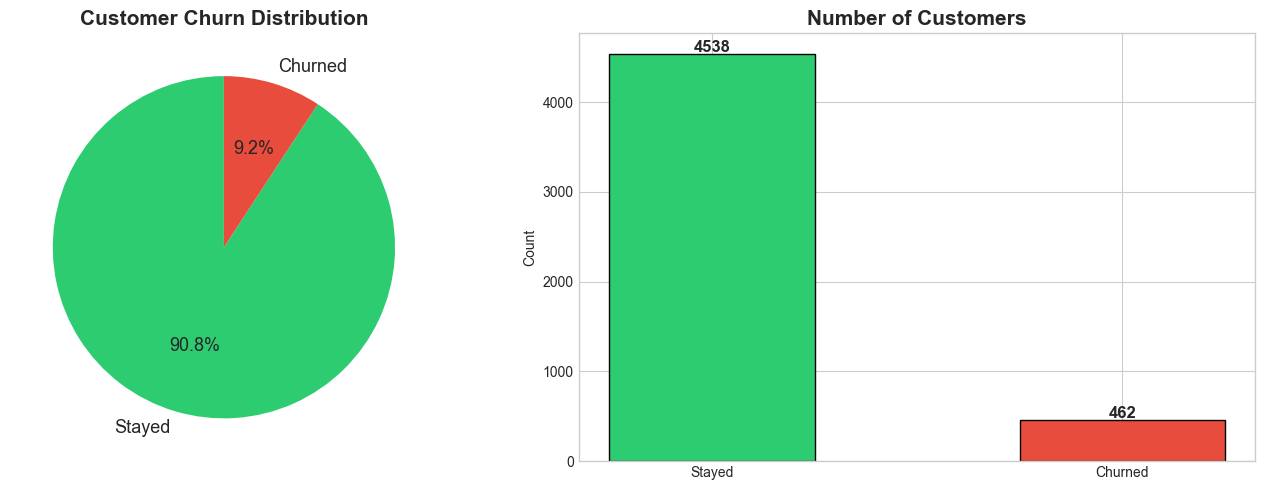

📊 Chart saved!


In [8]:
# Visualize the churn distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Pie chart
axes[0].pie(churn_counts.values, labels=['Stayed', 'Churned'], 
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], 
            startangle=90, textprops={'fontsize': 13})
axes[0].set_title('Customer Churn Distribution', fontsize=15, fontweight='bold')

# Chart 2: Bar chart with counts
bars = axes[1].bar(['Stayed', 'Churned'], churn_counts.values, 
                   color=['#2ecc71', '#e74c3c'], width=0.5, edgecolor='black')
for bar, count in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
                 str(count), ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Number of Customers', fontsize=15, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("📊 Chart saved!")

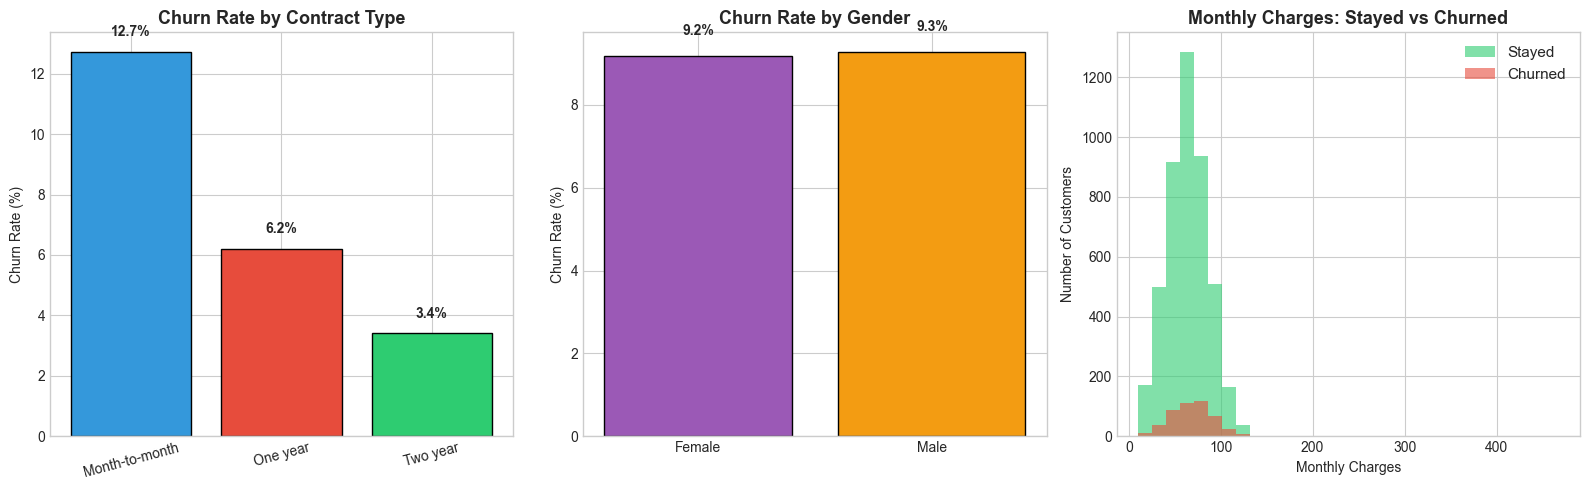

In [9]:
# How does contract type affect churn?
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Churn by Contract Type
contract_churn = df.groupby('contract_type')['churned'].mean() * 100
axes[0].bar(contract_churn.index, contract_churn.values, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(contract_churn.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Churn by Gender
gender_churn = df.groupby('gender')['churned'].mean() * 100
axes[1].bar(gender_churn.index, gender_churn.values, color=['#9b59b6', '#f39c12'], edgecolor='black')
axes[1].set_title('Churn Rate by Gender', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(gender_churn.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Monthly Charges Distribution for Churned vs Stayed
df[df['churned']==0]['monthly_charges'].hist(ax=axes[2], alpha=0.6, label='Stayed', bins=30, color='#2ecc71')
df[df['churned']==1]['monthly_charges'].hist(ax=axes[2], alpha=0.6, label='Churned', bins=30, color='#e74c3c')
axes[2].set_title('Monthly Charges: Stayed vs Churned', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Monthly Charges')
axes[2].set_ylabel('Number of Customers')
axes[2].legend(fontsize=11)

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=100, bbox_inches='tight')
plt.show()

### 💡 What We Observed:
- Month-to-month customers churn more than yearly contract customers
- Higher monthly charges → higher chance of churn
- These insights make business sense!

---
## 5. 🔧 Preparing the Data for the Model

Machine Learning models only understand **numbers**. But our dataset has text (like 'Male', 'Female', 'Bengaluru'). We need to **convert everything to numbers**.

This process is called **Preprocessing**.

In [10]:
# Step 1: Drop columns we don't need
# customer_id is just an ID - it doesn't help predict churn
df_model = df.drop(['customer_id'], axis=1)

# Step 2: Handle missing values
# Fill missing numbers with the median (middle value)
numeric_cols = df_model.select_dtypes(include=[np.number]).columns
df_model[numeric_cols] = df_model[numeric_cols].fillna(df_model[numeric_cols].median())

print("Remaining missing values:", df_model.isnull().sum().sum())

Remaining missing values: 150


In [11]:
# Step 3: Convert text columns to numbers
# This is called 'Label Encoding' - each unique text gets a number
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Identify text (categorical) columns
cat_cols = df_model.select_dtypes(include=['object']).columns
print(f"Text columns to convert: {list(cat_cols)}")

# Convert each text column
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"  ✅ '{col}' converted")

print("\nFirst 3 rows after encoding:")
df_model.head(3)

Text columns to convert: ['gender', 'city', 'education', 'contract_type', 'payment_method']
  ✅ 'gender' converted
  ✅ 'city' converted
  ✅ 'education' converted
  ✅ 'contract_type' converted
  ✅ 'payment_method' converted

First 3 rows after encoding:


,age,gender,city,education,tenure_months,contract_type,payment_method,monthly_charges,total_charges,num_products,has_credit_card,is_active_member,estimated_salary,churned
0,46.0,1,0,0,40,0,2,16.90,686.72,3,1,0,55083.68,1
1,28.0,0,1,2,22,1,1,88.73,2092.70,2,1,0,75325.39,0
2,52.0,0,4,0,7,2,3,67.45,449.61,1,1,1,57584.71,0


In [12]:
# Step 4: Separate Features (X) and Target (y)
# X = the inputs (what we know about the customer)
# y = the output (what we want to predict: churned or not)

X = df_model.drop('churned', axis=1)  # All columns EXCEPT 'churned'
y = df_model['churned']               # Only the 'churned' column

print(f"Features (X) shape: {X.shape}  → {X.shape[0]} customers, {X.shape[1]} features")
print(f"Target (y) shape:   {y.shape}  → one label per customer")
print(f"\nFeature names: {list(X.columns)}")

Features (X) shape: (5000, 13)  → 5000 customers, 13 features
Target (y) shape:   (5000,)  → one label per customer

Feature names: ['age', 'gender', 'city', 'education', 'tenure_months', 'contract_type', 'payment_method', 'monthly_charges', 'total_charges', 'num_products', 'has_credit_card', 'is_active_member', 'estimated_salary']


In [13]:
# Step 5: Split data into Training and Testing sets
# We train the model on 80% of data and test it on the remaining 20%
# This is like studying with 80% of practice questions and testing with the remaining 20%

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # Ensures we get the same split every time (reproducibility)
    stratify=y          # Ensures both splits have similar churn ratio
)

print(f"Training set:  {X_train.shape[0]} customers ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing set:   {X_test.shape[0]} customers  ({X_test.shape[0]/len(X)*100:.0f}%)")

Training set:  4000 customers (80%)
Testing set:   1000 customers  (20%)


In [14]:
# Step 6: Feature Scaling (Standardization)
# Logistic Regression works better when all numbers are on the same scale
# Think of it like converting all measurements to the same unit (cm, kg, etc.)
# StandardScaler makes all features have: mean = 0, std = 1

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler on TRAINING data only, then transform both train and test
# (We only 'learn' scaling parameters from training data to avoid data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Use the same scaler (don't fit again!)

print("✅ Data scaled successfully!")
print(f"Before scaling - Age mean: {X_train['age'].mean():.1f}, std: {X_train['age'].std():.1f}")
print(f"After scaling  - Age mean: {X_train_scaled[:,0].mean():.3f}, std: {X_train_scaled[:,0].std():.3f}")

✅ Data scaled successfully!
Before scaling - Age mean: 42.0, std: 12.1
After scaling  - Age mean: 0.000, std: 1.000


---
## 6. 🤖 Building the Logistic Regression Model

In [ ]:
# Import Logistic Regression from scikit-learn
from sklearn.linear_model import LogisticRegression

# Create the model
# max_iter=1000 means the model will try up to 1000 times to find the best answer
model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model!
# .fit() = 'teach' the model by showing it the training data
print("🚀 Training the model...")
model.fit(X_train_scaled, y_train)
print("✅ Model trained successfully!")

🚀 Training the model...
✅ Model trained successfully!


In [20]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

# Random Forest
from sklearn.ensemble import RandomForestClassifier

dt = DecisionTreeClassifier(max_depth=5, min_samples_split=2, min_samples_leaf=1, random_state=42)
rf = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=2, min_samples_leaf=1, random_state=42)

print("🚀 Training the tree model...")
dt.fit(X_train_scaled, y_train)
print("🚀 Training the random forest model...")
rf.fit(X_train_scaled, y_train)
print("✅ Both models trained successfully!")

🚀 Training the tree model...
🚀 Training the random forest model...
✅ Both models trained successfully!


In [16]:
# Let's see what the model learned: the coefficients
# Positive coefficient → this feature increases churn probability
# Negative coefficient → this feature decreases churn probability
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("Top features influencing churn:")
print(coefficients.to_string(index=False))

Top features influencing churn:
         Feature  Coefficient
   tenure_months    -0.636343
   contract_type    -0.587551
is_active_member    -0.401379
    num_products     0.182480
 monthly_charges     0.122781
  payment_method     0.120145
estimated_salary    -0.112476
   total_charges     0.094297
            city     0.054425
             age     0.044510
       education     0.032232
 has_credit_card     0.030200
          gender    -0.002626


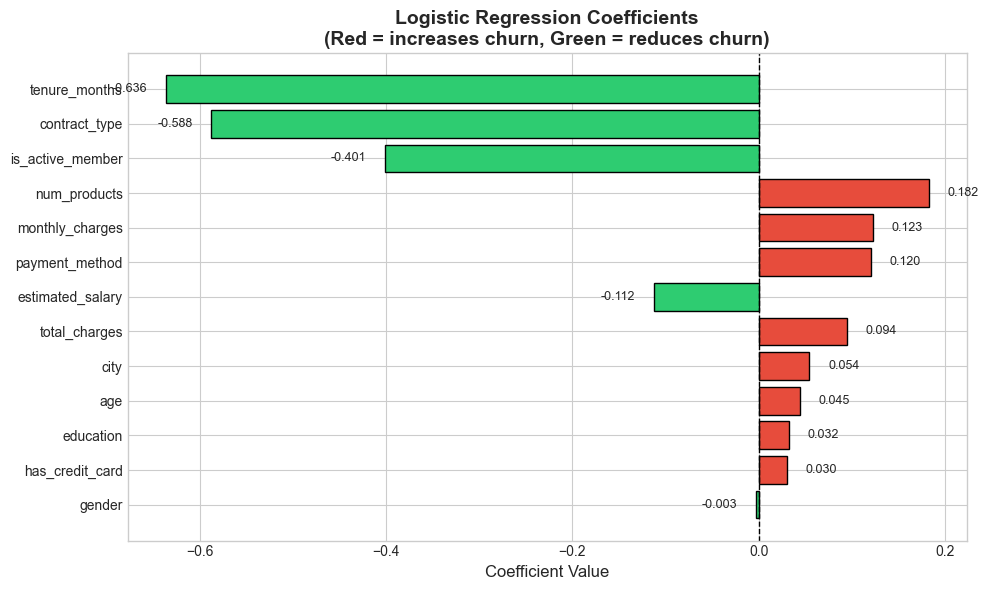

In [17]:
# Visualize the coefficients
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coefficients['Coefficient']]
bars = ax.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors, edgecolor='black')
ax.axvline(x=0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title('Logistic Regression Coefficients\n(Red = increases churn, Green = reduces churn)', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, coefficients['Coefficient']):
    ax.text(val + (0.02 if val >= 0 else -0.02), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 7. 🔮 Making Predictions

In [18]:
# Make predictions on the test set
# .predict() gives us the final decision: 0 (stay) or 1 (churn)
y_pred = model.predict(X_test_scaled)

# .predict_proba() gives us the PROBABILITY of each outcome
# Column 0 = probability of staying, Column 1 = probability of churning
y_prob = model.predict_proba(X_test_scaled)

print("Sample predictions (first 10 customers):")
print(f"{'Actual':<10} {'Predicted':<12} {'Churn Probability':<20}")
print("-" * 45)
for i in range(10):
    actual = y_test.values[i]
    predicted = y_pred[i]
    prob = y_prob[i][1]  # probability of churning
    status = "✅ Correct" if actual == predicted else "❌ Wrong"
    print(f"{actual:<10} {predicted:<12} {prob:.3f} ({prob*100:.1f}%)   {status}")

Sample predictions (first 10 customers):
Actual     Predicted    Churn Probability   
---------------------------------------------
0          0            0.087 (8.7%)   ✅ Correct
0          0            0.111 (11.1%)   ✅ Correct
0          0            0.047 (4.7%)   ✅ Correct
1          0            0.114 (11.4%)   ❌ Wrong
0          0            0.158 (15.8%)   ✅ Correct
0          0            0.167 (16.7%)   ✅ Correct
0          0            0.022 (2.2%)   ✅ Correct
0          0            0.025 (2.5%)   ✅ Correct
0          0            0.183 (18.3%)   ✅ Correct
0          0            0.048 (4.8%)   ✅ Correct


In [21]:
# Make predictions on the test set using the Decision Tree model
# .predict() gives us the final decision: 0 (stay) or 1 (churn)
y_pred = dt.predict(X_test_scaled)

# .predict_proba() gives us the PROBABILITY of each outcome
# Column 0 = probability of staying, Column 1 = probability of churning
y_prob = dt.predict_proba(X_test_scaled)

print("Sample predictions (first 10 customers):")
print(f"{'Actual':<10} {'Predicted':<12} {'Churn Probability':<20}")
print("-" * 45)
for i in range(10):
    actual = y_test.values[i]
    predicted = y_pred[i]
    prob = y_prob[i][1]  # probability of churning
    status = "✅ Correct" if actual == predicted else "❌ Wrong"
    print(f"{actual:<10} {predicted:<12} {prob:.3f} ({prob*100:.1f}%)   {status}")

Sample predictions (first 10 customers):
Actual     Predicted    Churn Probability   
---------------------------------------------
0          0            0.158 (15.8%)   ✅ Correct
0          0            0.064 (6.4%)   ✅ Correct
0          0            0.029 (2.9%)   ✅ Correct
1          0            0.126 (12.6%)   ❌ Wrong
0          0            0.126 (12.6%)   ✅ Correct
0          0            0.236 (23.6%)   ✅ Correct
0          0            0.090 (9.0%)   ✅ Correct
0          0            0.061 (6.1%)   ✅ Correct
0          0            0.081 (8.1%)   ✅ Correct
0          0            0.028 (2.8%)   ✅ Correct


In [22]:
# Make predictions on the test set using the Random Forest model
# .predict() gives us the final decision: 0 (stay) or 1 (churn)
y_pred = rf.predict(X_test_scaled)

# .predict_proba() gives us the PROBABILITY of each outcome
# Column 0 = probability of staying, Column 1 = probability of churning
y_prob = rf.predict_proba(X_test_scaled)

print("Sample predictions (first 10 customers):")
print(f"{'Actual':<10} {'Predicted':<12} {'Churn Probability':<20}")
print("-" * 45)
for i in range(10):
    actual = y_test.values[i]
    predicted = y_pred[i]
    prob = y_prob[i][1]  # probability of churning
    status = "✅ Correct" if actual == predicted else "❌ Wrong"
    print(f"{actual:<10} {predicted:<12} {prob:.3f} ({prob*100:.1f}%)   {status}")

Sample predictions (first 10 customers):
Actual     Predicted    Churn Probability   
---------------------------------------------
0          0            0.095 (9.5%)   ✅ Correct
0          0            0.092 (9.2%)   ✅ Correct
0          0            0.053 (5.3%)   ✅ Correct
1          0            0.147 (14.7%)   ❌ Wrong
0          0            0.151 (15.1%)   ✅ Correct
0          0            0.169 (16.9%)   ✅ Correct
0          0            0.036 (3.6%)   ✅ Correct
0          0            0.055 (5.5%)   ✅ Correct
0          0            0.126 (12.6%)   ✅ Correct
0          0            0.059 (5.9%)   ✅ Correct


---
## 8. 📏 Evaluating the Model

Now let's measure how good our predictions are.

In [19]:
# Detailed Classification Report
print("Detailed Classification Report:")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Churned (1)']))
print()
print("Explanation of terms:")
print("  Precision: Of all customers I predicted would churn, how many actually did?")
print("  Recall:    Of all customers who actually churned, how many did I catch?")
print("  F1-score:  A balance between Precision and Recall")

Detailed Classification Report:


NameError: name 'classification_report' is not defined

In [ ]:
# Visualize: Confusion Matrix + ROC Curve side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted: Stayed', 'Predicted: Churned'],
            yticklabels=['Actual: Stayed', 'Actual: Churned'],
            linewidths=2, linecolor='white', annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Add labels
total = cm.sum()
axes[0].text(0.5, -0.15, 
    f'TN={cm[0,0]} | FP={cm[0,1]} | FN={cm[1,0]} | TP={cm[1,1]}',
    ha='center', transform=axes[0].transAxes, fontsize=10, color='navy')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guessing')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve', fontsize=15, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=11)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('lr_evaluation.png', dpi=100, bbox_inches='tight')
plt.show()

### 📖 Reading the Confusion Matrix

```
                  Predicted: Stayed  |  Predicted: Churned
Actual: Stayed  |  True Negative(TN) |  False Positive(FP)
Actual: Churned |  False Negative(FN)|  True Positive(TP)
```

- **True Negative (TN):** Correctly predicted the customer would stay ✅
- **True Positive (TP):** Correctly predicted the customer would churn ✅  
- **False Positive (FP):** Predicted churn, but customer actually stayed ❌ (unnecessary offer)
- **False Negative (FN):** Predicted stay, but customer actually churned ❌ (missed at-risk customer!)

**For business:** False Negatives are costly — we missed customers who left!

---
## 9. 🎓 Key Takeaways

### What We Did:
1. ✅ Loaded customer data and explored it
2. ✅ Cleaned the data (handled missing values)
3. ✅ Converted text to numbers (Label Encoding)
4. ✅ Scaled the features (StandardScaler)
5. ✅ Split into training (80%) and testing (20%) sets
6. ✅ Built a Logistic Regression model
7. ✅ Evaluated with Accuracy, Confusion Matrix, and ROC-AUC

### When to Use Logistic Regression?
- ✅ When you have a **binary outcome** (Yes/No, Fraud/Not Fraud, Sick/Healthy)
- ✅ When you want to understand **which features matter most** (interpretable)
- ✅ When your dataset is **not too large** (it's fast and simple)
- ⚠️ If the data is complex with many non-linear patterns, other models might do better

### Real-World Applications:
- 🏦 Loan default prediction
- 🏥 Disease diagnosis (sick or healthy?)
- 📧 Email spam detection
- 🛒 Purchase prediction


In [ ]:
from sklearn.metrics import (accuracy_score, confusion_matrix, 
                              classification_report, roc_auc_score, roc_curve)

# Accuracy: What % of predictions were correct?
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   → Our model is correct {accuracy*100:.2f}% of the time\n")

# ROC-AUC Score: Measures how well the model separates the two classes
# 0.5 = random guessing, 1.0 = perfect
roc_auc = roc_auc_score(y_test, y_prob[:, 1])
print(f"📈 ROC-AUC Score: {roc_auc:.4f}")
print(f"   → The closer to 1.0, the better (0.5 = random guessing)")

In [ ]:
# Final Summary
print("=" * 50)
print("       LOGISTIC REGRESSION SUMMARY")
print("=" * 50)
print(f"  Dataset:      Customer Churn")
print(f"  Total records:{len(df)}")
print(f"  Train / Test: {len(X_train)} / {len(X_test)}")
print(f"  Accuracy:     {accuracy*100:.2f}%")
print(f"  ROC-AUC:      {roc_auc:.4f}")
print("=" * 50)
print("Next Step: Try K-Nearest Neighbors on the same data!")